### Objective:

To build a model to predict whether an individual is at risk of diabetes or not.

#### Data Dictionary

* `Pregnancies`: Number of times pregnant
* `Glucose`: Plasma glucose concentration over 2 hours in an oral glucose tolerance test
* `BloodPressure`: Diastolic blood pressure (mm Hg)
* `SkinThickness`: Triceps skinfold thickness (mm)
* `Insulin`: 2-Hour serum insulin (mu U/ml)
* `BMI`: Body mass index (weight in kg/(height in m)^2)
* `Pedigree`: Diabetes pedigree function - A function that scores likelihood of diabetes based on family history.
* `Age`: Age in years
* `Class`: Class variable (0: the person is not diabetic or 1: the person is diabetic)

In [1]:
# Library to suppress warnings or deprecation notes 
import warnings
warnings.filterwarnings('ignore')

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Library to split data 
from sklearn.model_selection import train_test_split

# Libraries to import decision tree classifier and different ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Libtune to tune model, get different metric scores
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score,f1_score,roc_auc_score
from sklearn.model_selection import GridSearchCV

### Data Exploration

In [2]:
pima=pd.read_csv("data/25_pima-indians-diabetes.csv")

In [3]:
# copying data to another varaible to avoid any changes to original data
data=pima.copy()

#### Review top and bottom 5 rows

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


#### Dataset Shape

In [6]:
data.shape

(768, 9)

* There are 768 observations and 9 columns in the dataset

#### Check Datatype

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Class          768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


***Observations -***
* *All variables are integer or float types*
* *There are no null values in the dataset*

#### Statistical Summary

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
Pedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


***Observations -***
* *We have data of women with an average of 4 pregnancies.*
* *Variables like Glucose, BloodPressure, SkinThickness, and Insulin have minimum values of 0 which might be data input errors and we should explore it further.*
* *There is a large difference between the 3rd quartile and maximum value for variables like SkinThickness, Insulin, and Age which suggest that there might be outliers present in the data.*

### Exploratory Data Analysis

#### Univariate analysis

**Helper Functions**

In [9]:
# Function to create a histogram and boxplot combined for visualization of numerical features for Univariate Analysis
def num_analysis_hist_box(data, feature, figsize=(10, 5)):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10,5))
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)  # creating the 2 subplots
    
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="lightgreen")  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist2, color='skyblue')  # For histogram
    
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")  # Add mean to the histogram
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")  # Add median to the histogram

#### Observations on Pregnancies

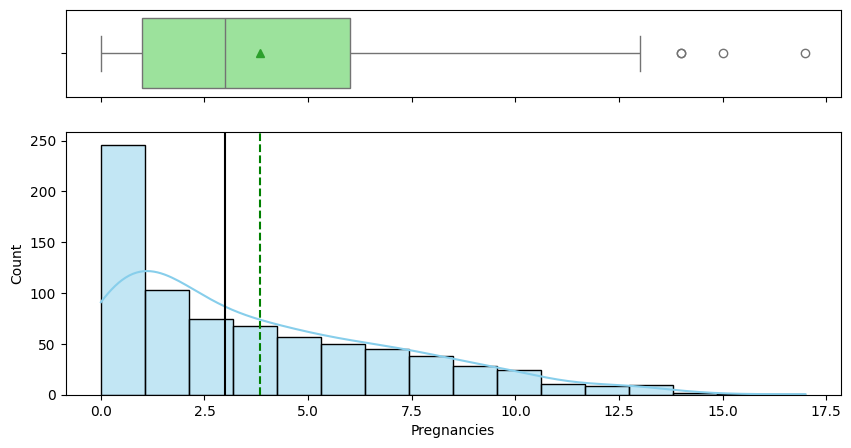

In [10]:
num_analysis_hist_box(data, "Pregnancies")

* *Right Skewed, contains outliers. Per data, Range of 3rd and 1st Quartile is between 1 and 6*

#### Observations on Glucose

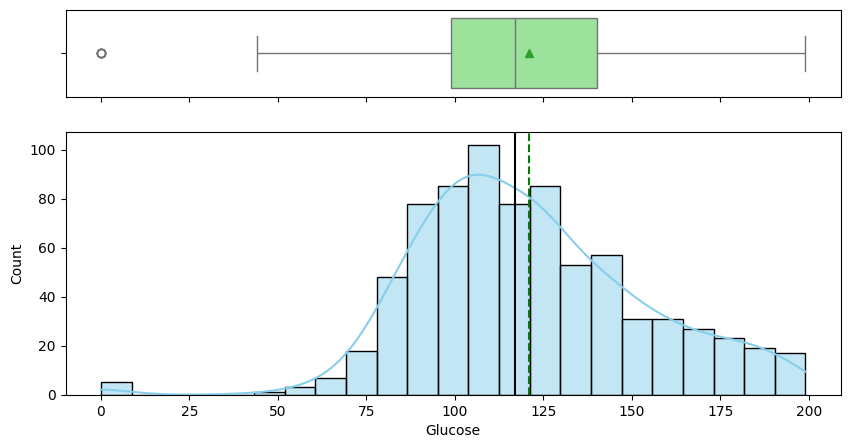

In [11]:
num_analysis_hist_box(data,"Glucose")

* *Fairly Normal Distribution, shows zero glucose, possibly indicating data error*

#### Observations on BloodPressure

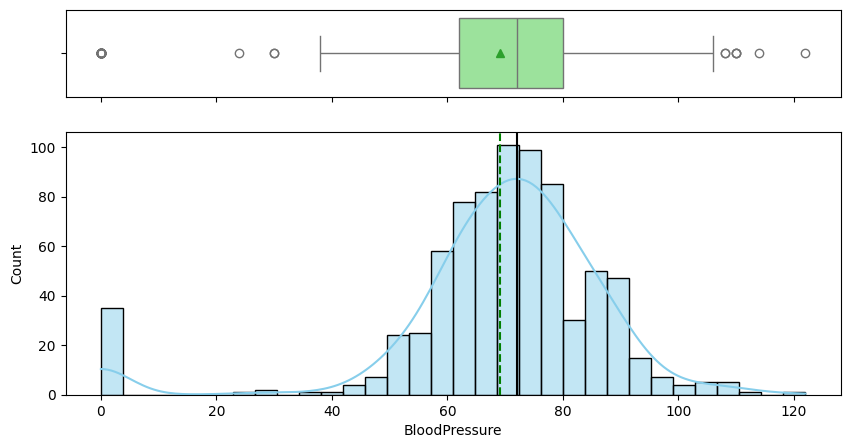

In [12]:
num_analysis_hist_box(data,"BloodPressure")

* *Fairly Normal Distribution. Outliers with BP less than 40 seems unlikely*

#### Observations on SkinThickness

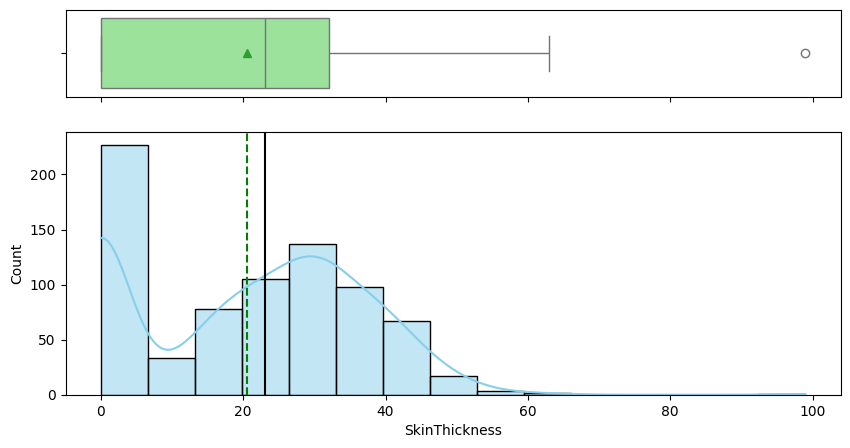

In [13]:
num_analysis_hist_box(data,"SkinThickness")

* *Many have close to zero which seems unlikely*

#### Observations on Insulin

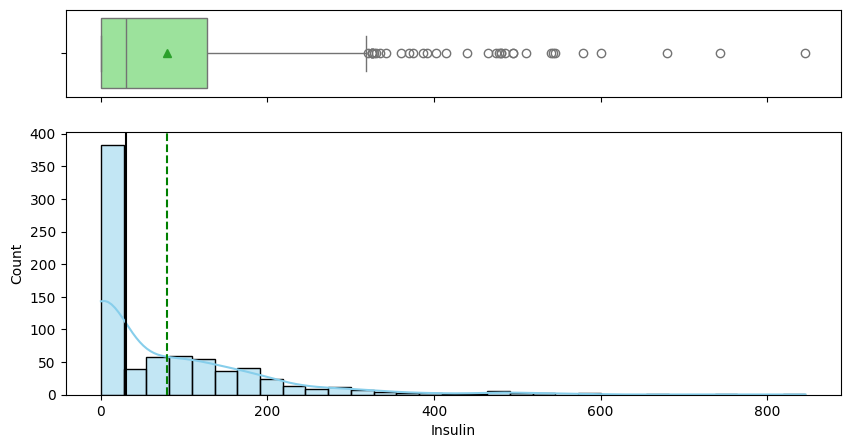

In [14]:
num_analysis_hist_box(data,"Insulin")

* *Right Skewed, with many outliers > 300, Many with zero*

#### Observations on BMI

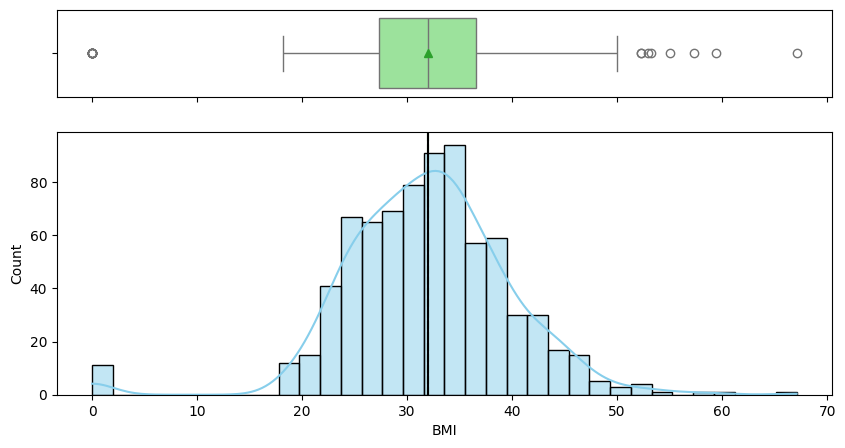

In [15]:
num_analysis_hist_box(data,"BMI")

* *Fairly normal with outliers at zero and > 50*

#### Observations on Pedigree

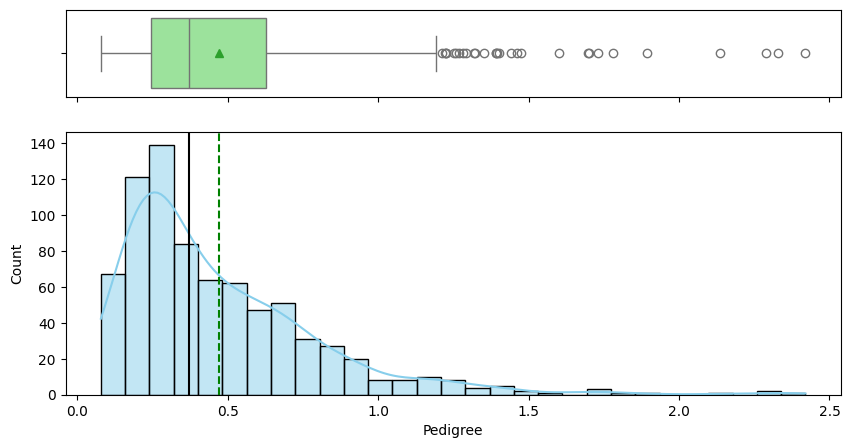

In [16]:
num_analysis_hist_box(data,"Pedigree")

* *Right Skewed, several outliers on higher side*

#### Observations on Age

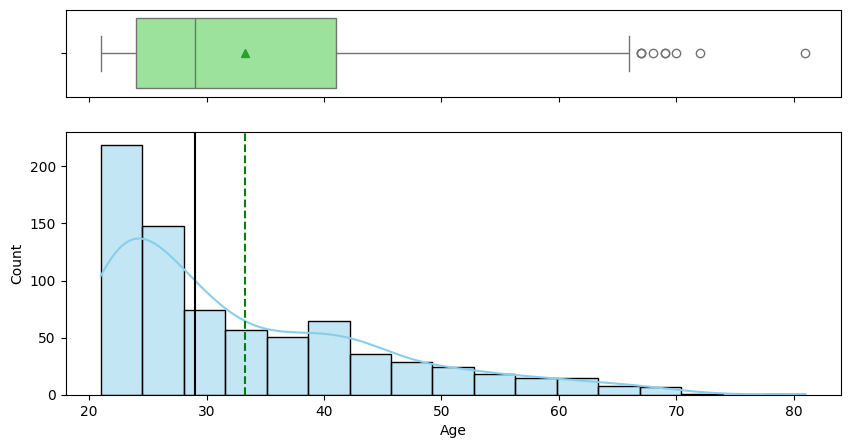

In [17]:
num_analysis_hist_box(data,"Age")

* *Right Skewed with outliers above 65 or so*

In [18]:
# Function to plot count and percentage barplots side by side for categorical features for Univariate Analysis
def cat_analysis_count_and_perct(data, column, figsize=(12, 5)):
    """
    Plots two countplots side by side: one with count labels, one with percentage labels.
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        column (str): The column to plot.
        figsize (tuple): Figure size for the plots.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    categories = data[column].value_counts().index
    total = len(data)
    
    # Countplot with count labels
    ax1 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[0], palette='Set2')
    axes[0].set_title('Counts per ' + column)
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=90)
    for p in ax1.patches:
        count = int(p.get_height())
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black')
    
    # Countplot with percentage labels
    ax2 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[1], palette='Set2')
    axes[1].set_title('Percentage per ' + column)
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=90)
    for p in ax2.patches:
        percent = 100 * p.get_height() / total
        ax2.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.show()

#### Observations on Class

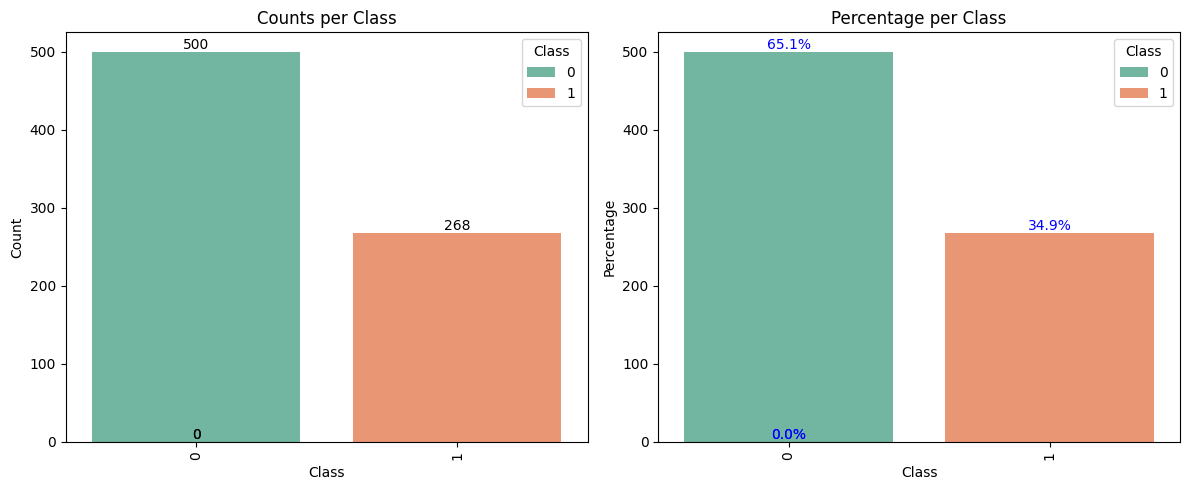

In [19]:
cat_analysis_count_and_perct(data,"Class")

* *The data is slightly imbalanced as there are only ~35% of the women in data who are diabetic and ~65% of women who are not diabetic.*

#### Observations on Preg

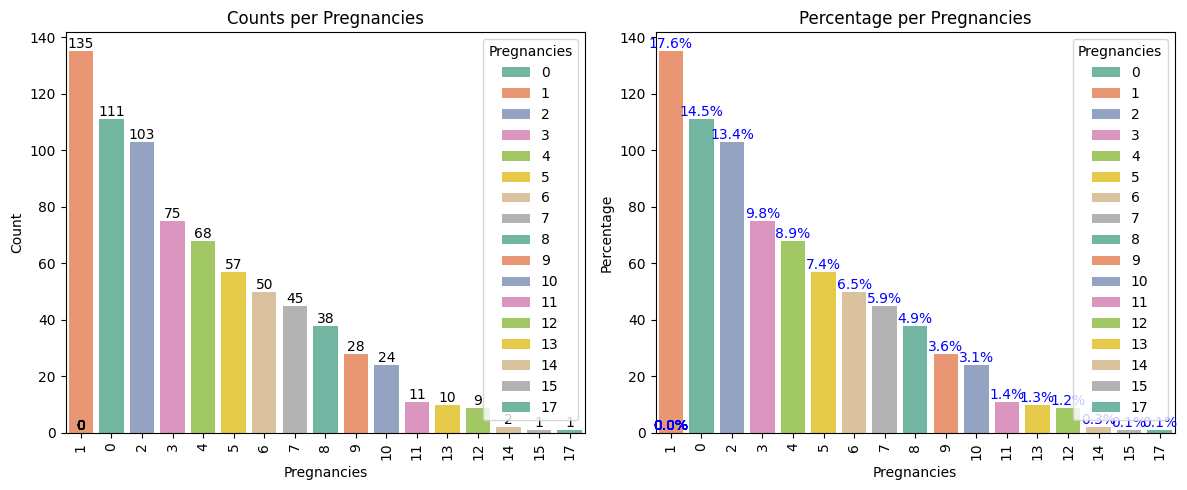

In [20]:
cat_analysis_count_and_perct(data,"Pregnancies")

* *The most common number of pregnancies amongst women is 1.*
* *Surprisingly, there are many observations with more than 10 pregnancies.*

#### Bivariate Analysis

**Helper Function**

In [21]:
### function to plot distributions wrt target
def num_feature_vs_target(data, predictor, target):
    sns.boxplot(data=data, x=target, y=predictor, palette="Set2", hue=target, showfliers=False);
    plt.title(f'{predictor} distribution by {target}');
    plt.tight_layout()
    plt.show()


#### Pregnancies vs Class

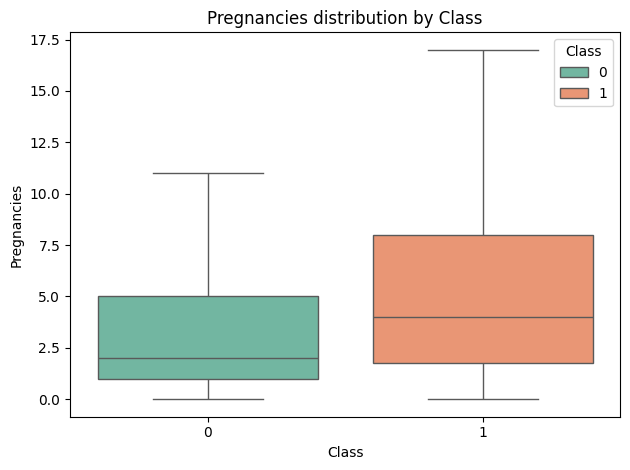

In [22]:
num_feature_vs_target(data, "Pregnancies", "Class")

*Diabeties is found more in Pregnant Women*

#### Glucose vs Class

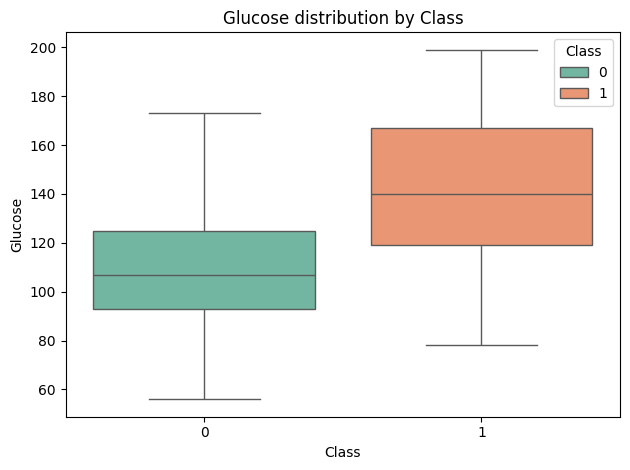

In [23]:
num_feature_vs_target(data, "Glucose", "Class")

*Women with diabetes have higher plasma glucose concentrations.*

#### BloodPressure vs Class

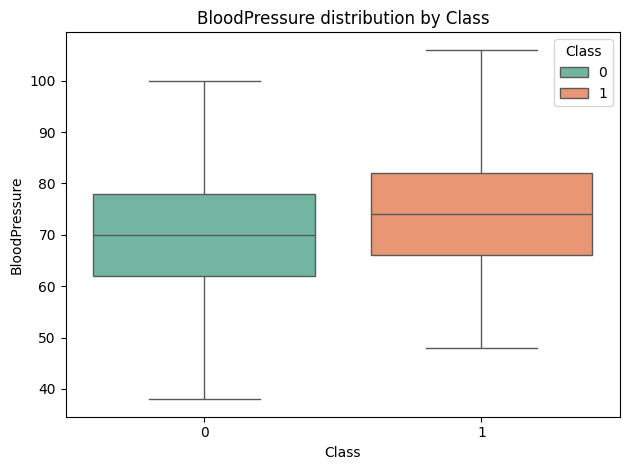

In [24]:
num_feature_vs_target(data, "BloodPressure", "Class")

*Blood Pressure levels are slightly higher for Diabeties cases*

#### SkinThickness vs Class

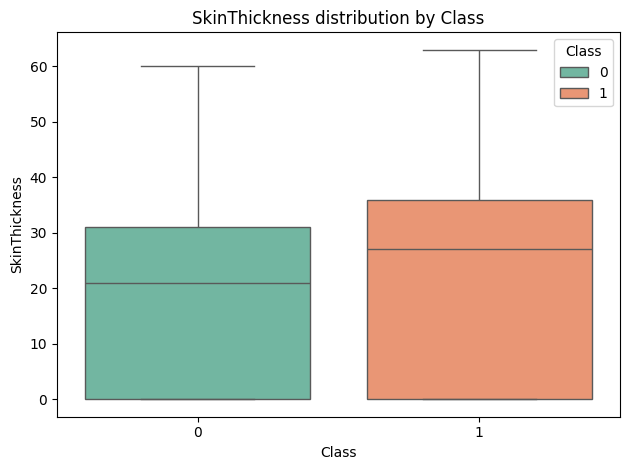

In [25]:
num_feature_vs_target(data, "SkinThickness", "Class")

*Not much difference in both classes*

#### Insulin vs Class

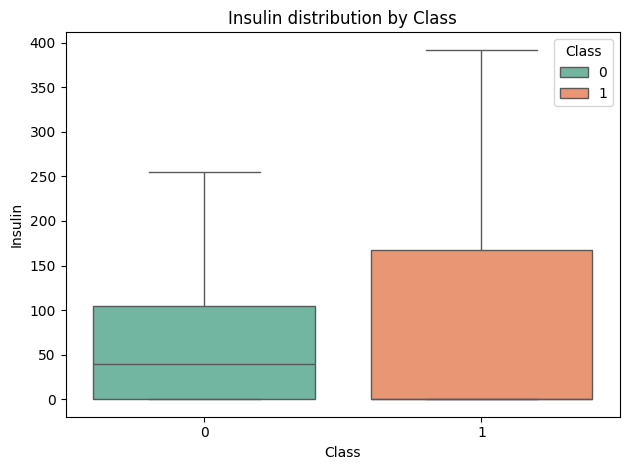

In [26]:
num_feature_vs_target(data, "Insulin", "Class")

*Levels of Insulin are higher for Diabeties cases per the given data*

#### BMI vs Class

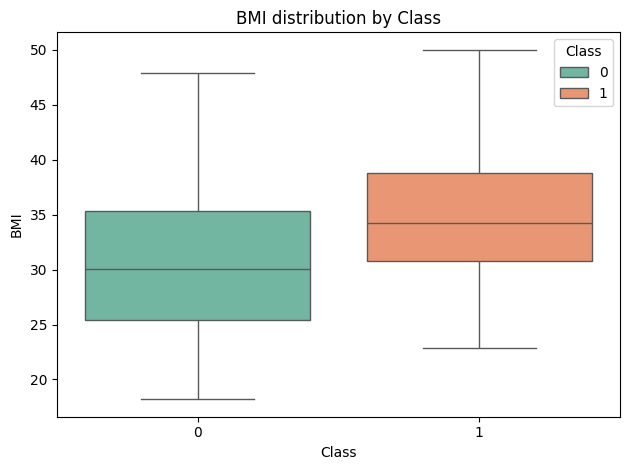

In [27]:
num_feature_vs_target(data, "BMI", "Class")

*As expected, diabeties cases have higher BMI*

#### Pedigree vs Class

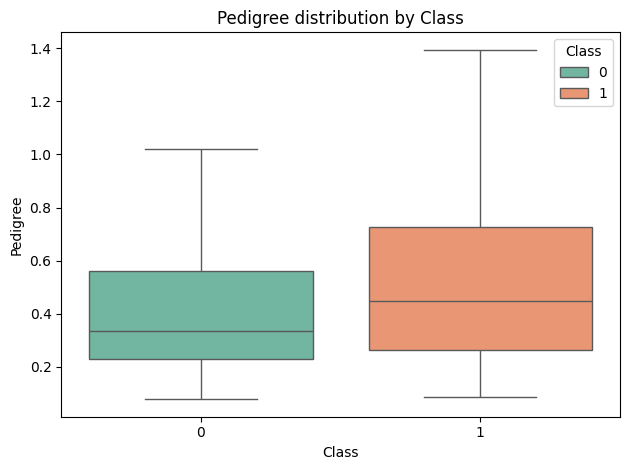

In [28]:
num_feature_vs_target(data, "Pedigree", "Class")

*Diabetic women have a higher diabetes pedigree function values.*

#### Age vs Class

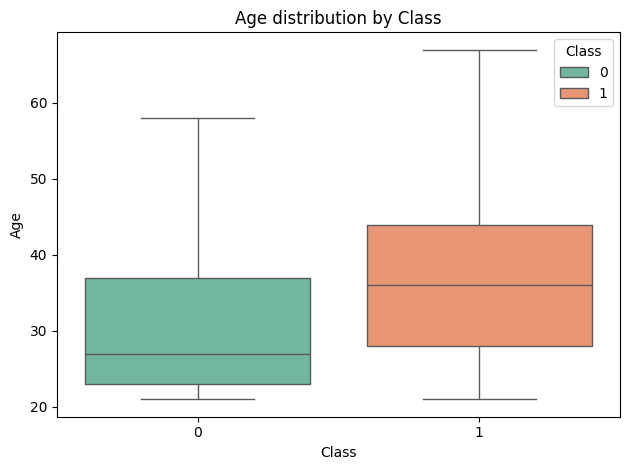

In [29]:
num_feature_vs_target(data, "Age", "Class")

*Diabeties cases are more in women with higher Age*

#### Multivariate

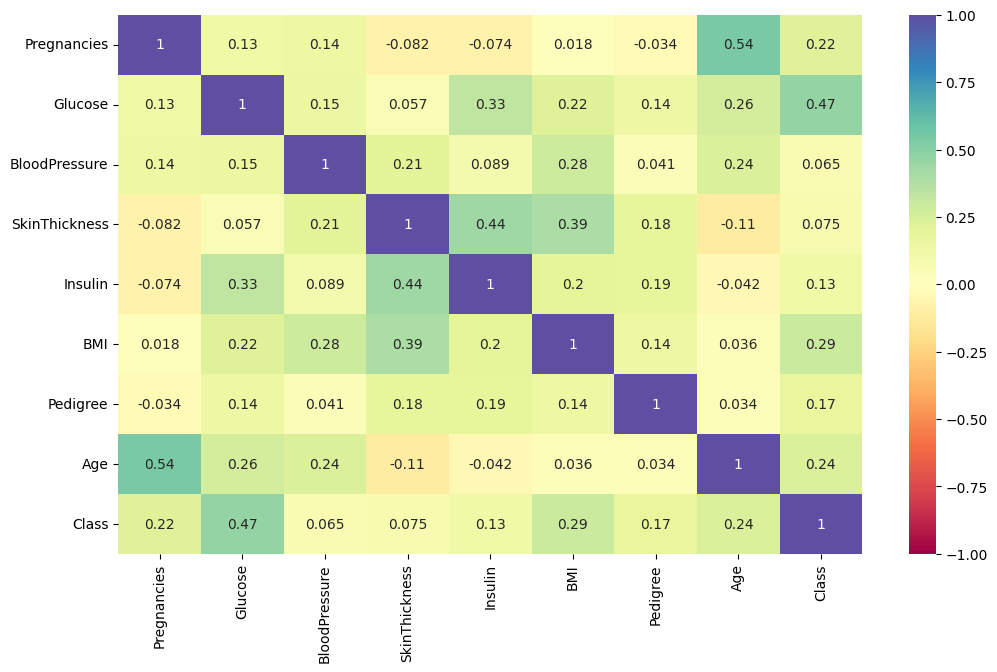

In [30]:
plt.figure(figsize=(12,7))
sns.heatmap(data.corr(),annot=True,vmin=-1,vmax=1,cmap="Spectral")
plt.show()

***Observations-***
* *Dependent variable class shows a moderate correlation with 'Glucose'.*
* *There is a positive correlation between age and the number of pregnancies which makes sense.*
* *Insulin and skin thickness also shows a moderate positive correlation.*

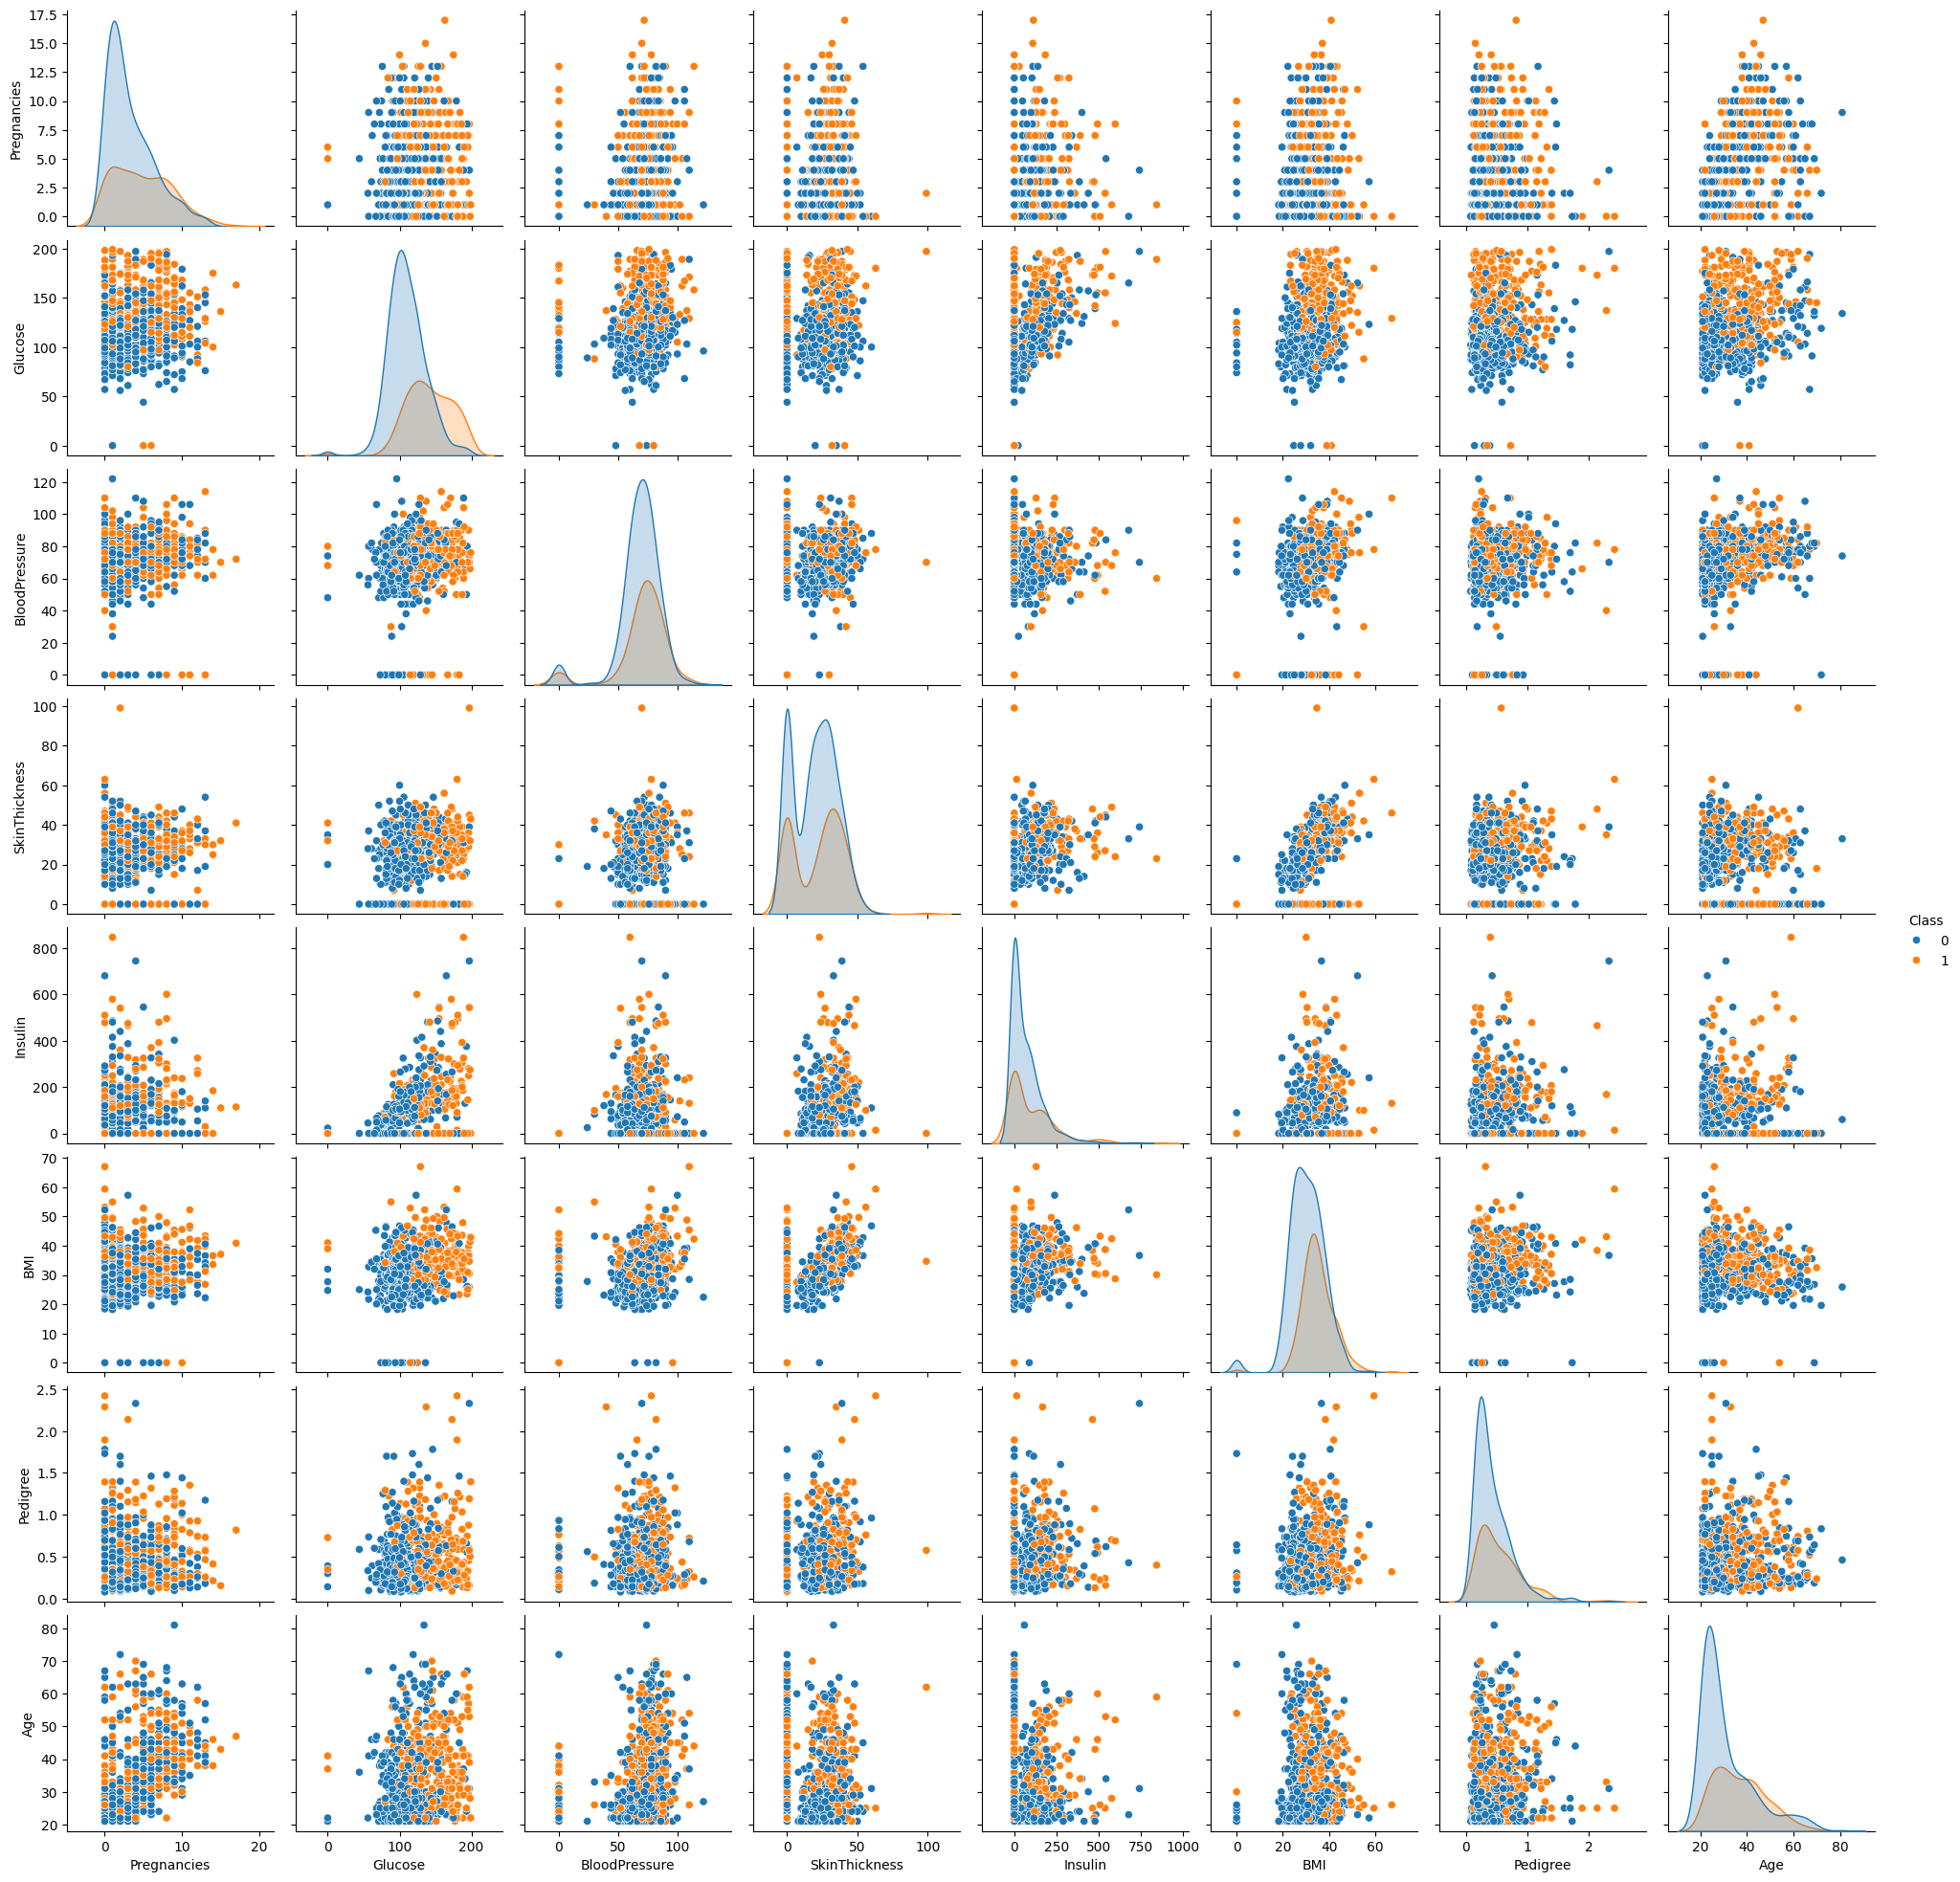

In [31]:
sns.pairplot(data=data,hue="Class")
plt.show()

### Missing value treatment

In [32]:
data.loc[data.Glucose == 0, 'Glucose'] = data.Glucose.median()
data.loc[data.BloodPressure == 0, 'BloodPressure'] = data.BloodPressure.median()
data.loc[data.SkinThickness == 0, 'SkinThickness'] = data.SkinThickness.median()
data.loc[data.Insulin == 0, 'Insulin'] = data.Insulin.median()
data.loc[data.BMI == 0, 'BMI'] = data.BMI.median()

* 0 values replaced by the median of the respective variable

### Model Building

In [33]:
# Define features and target
X = data.drop('Class',axis=1)
y = data['Class'] 

In [34]:
# Splitting data into training and test set:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1,stratify=y)
print(X_train.shape, X_test.shape)

(537, 8) (231, 8)


**The Stratify arguments maintain the original distribution of classes in the target variable while splitting the data into train and test sets.**

In [35]:
y.value_counts(1)

Class
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [36]:
y_test.value_counts(1)

Class
0    0.649351
1    0.350649
Name: proportion, dtype: float64

#### *Model evaluation criterion*

#### *The model can make wrong predictions as:*
1. *Predicting a person doesn't have diabetes and the person has diabetes. False Negative*
2. *Predicting a person has diabetes, and the person doesn't have diabetes. False Positive*

#### *Which case is more important?*
* *Predicting a person doesn't have diabetes, and the person has diabetes. Reduce False Negative*

**Helper Function**

In [37]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [38]:
# Confusion Matrix for classification
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

#### 1. Decision Tree

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.731602  0.580247   0.626667  0.602564


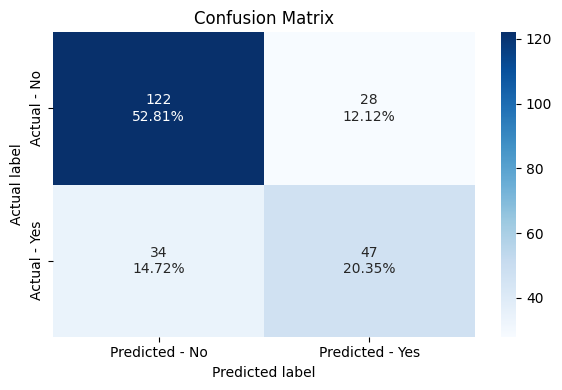

In [39]:
#Fitting the model
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train,y_train)

#Calculating different metrics
dtree_model_train_perf=model_performance_classification_sklearn(d_tree,X_train,y_train)
print("Training performance:\n",dtree_model_train_perf)
dtree_model_test_perf=model_performance_classification_sklearn(d_tree,X_test,y_test)
print("Testing performance:\n",dtree_model_test_perf)
#Creating confusion matrix
confusion_matrix_sklearn(d_tree, X_test, y_test)

* *The decision tree is overfitting the training data as there is a huge difference between training and test scores for all the metrics.*
* *The test recall is very low i.e. only 58%.*

#### 2. Random Forest

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy   Recall  Precision        F1
0  0.753247  0.54321     0.6875  0.606897


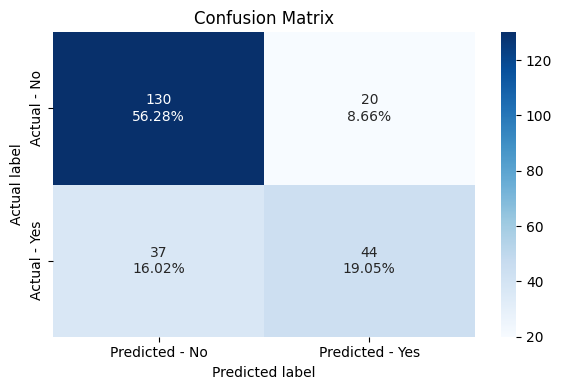

In [40]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

#Calculating different metrics
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator,X_train,y_train)
print("Training performance:\n",rf_estimator_model_train_perf)
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator,X_test,y_test)
print("Testing performance:\n",rf_estimator_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_estimator, X_test, y_test)

* *Random forest is overfitting the training data as there is a huge difference between training and test scores for all the metrics.*
* *The test recall is even lower than the decision tree but has a higher test precision.*

#### 3. Bagging Classifier

Training performance:
    Accuracy    Recall  Precision        F1
0  0.994413  0.983957        1.0  0.991914
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.744589  0.555556   0.661765  0.604027


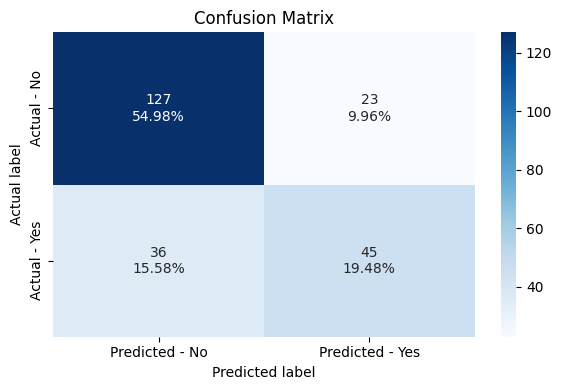

In [41]:
#Fitting the model
bagging_classifier = BaggingClassifier(random_state=1)
bagging_classifier.fit(X_train,y_train)

#Calculating different metrics
bagging_classifier_model_train_perf=model_performance_classification_sklearn(bagging_classifier,X_train,y_train)
print("Training performance:\n",bagging_classifier_model_train_perf)
bagging_classifier_model_test_perf=model_performance_classification_sklearn(bagging_classifier,X_test,y_test)
print("Testing performance:\n",bagging_classifier_model_test_perf)
#Creating confusion matrix
confusion_matrix_sklearn(bagging_classifier, X_test, y_test)

* *Bagging classifier giving a similar performance as random forest.*
* *It is also overfitting the training data and lower test recall than decision trees.*

#### 4. Tuning Decision Tree

In [42]:
#Choose the type of classifier. 
dtree_estimator = DecisionTreeClassifier(class_weight={0:0.35,1:0.65},random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2,10), 
              'min_samples_leaf': [5, 7, 10, 15],
              'max_leaf_nodes' : [2, 3, 5, 10,15],
              'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
dtree_estimator.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,np.int64(4)
,min_samples_split,2
,min_samples_leaf,7
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,15
,min_impurity_decrease,0.0001
,class_weight,"{0: 0.35, 1: 0.65}"


Training performance:
    Accuracy    Recall  Precision        F1
0  0.811918  0.871658   0.679167  0.763466
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.688312  0.691358   0.543689  0.608696


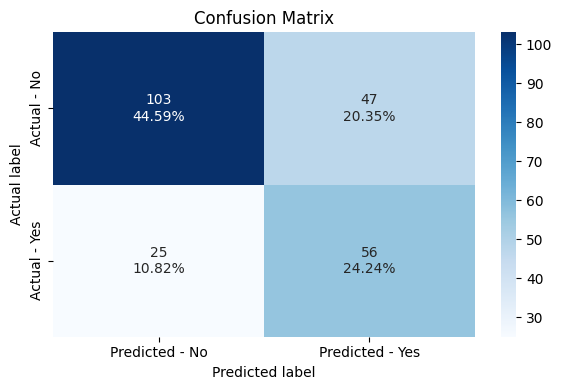

In [43]:
#Calculating different metrics
dtree_estimator_model_train_perf=model_performance_classification_sklearn(dtree_estimator,X_train,y_train)
print("Training performance:\n",dtree_estimator_model_train_perf)
dtree_estimator_model_test_perf=model_performance_classification_sklearn(dtree_estimator,X_test,y_test)
print("Testing performance:\n",dtree_estimator_model_test_perf)
#Creating confusion matrix
confusion_matrix_sklearn(dtree_estimator, X_test, y_test)

* *The test recall has increased significantly after hyperparameter tuning and the decision tree is giving a generalized performance.*
* *The confusion matrix shows that the model can identify the majority of patients who are at risk of diabetes.*

#### 5. Tuning Random Forest

In [44]:
# Choose the type of classifier. 
rf_tuned = RandomForestClassifier(class_weight={0:0.35,1:0.65},random_state=1)

parameters = {  
                'max_depth': list(np.arange(3,10,1)),
                'max_features': np.arange(0.6,1.1,0.1),
                'max_samples': np.arange(0.7,1.1,0.1),
                'min_samples_split': np.arange(2, 20, 5),
                'n_estimators': np.arange(30,160,20),
                'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer,cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
rf_tuned.fit(X_train, y_train)

,n_estimators,np.int64(30)
,criterion,'gini'
,max_depth,np.int64(6)
,min_samples_split,np.int64(2)
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,np.float64(0.6)
,max_leaf_nodes,None
,min_impurity_decrease,0.01
,bootstrap,True
,oob_score,False


Training performance:
    Accuracy    Recall  Precision        F1
0  0.815642  0.882353   0.681818  0.769231
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.748918  0.716049   0.623656  0.666667


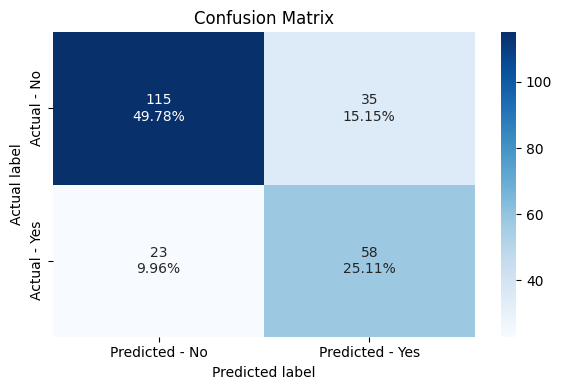

In [45]:
#Calculating different metrics
rf_tuned_model_train_perf=model_performance_classification_sklearn(rf_tuned,X_train,y_train)
print("Training performance:\n",rf_tuned_model_train_perf)
rf_tuned_model_test_perf=model_performance_classification_sklearn(rf_tuned,X_test,y_test)
print("Testing performance:\n",rf_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_tuned, X_test, y_test)

* *The test recall has increased significantly after hyperparameter tuning but the  model is still overfitting the training data.*
* *The confusion matrix shows that the model can identify the majority of patients who are at risk of diabetes.*

#### 6. Tuning Bagging Classifier

In [46]:
# Choose the type of classifier. 
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {'max_samples': [0.7,0.8,0.9,1], 
              'max_features': [0.7,0.8,0.9,1],
              'n_estimators' : [10,20,30,40,50],
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

,estimator,None
,n_estimators,50
,max_samples,0.7
,max_features,0.9
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,1
,verbose,0


Training performance:
    Accuracy    Recall  Precision        F1
0   0.98324  0.957219   0.994444  0.975477
Testing performance:
    Accuracy    Recall  Precision        F1
0   0.74026  0.518519   0.666667  0.583333


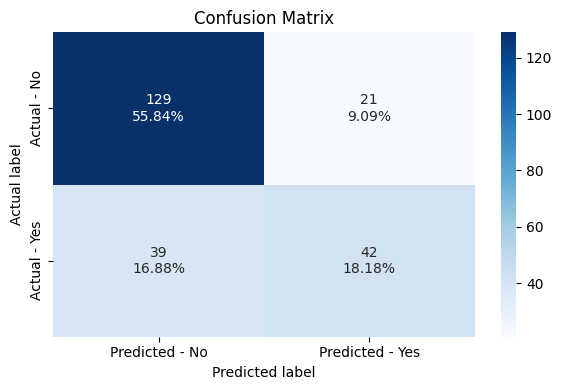

In [47]:
#Calculating different metrics
bagging_estimator_tuned_model_train_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_train,y_train)
print("Training performance:\n",bagging_estimator_tuned_model_train_perf)
bagging_estimator_tuned_model_test_perf=model_performance_classification_sklearn(bagging_estimator_tuned,X_test,y_test)
print("Testing performance:\n",bagging_estimator_tuned_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(bagging_estimator_tuned, X_test, y_test)

* *Surprisingly, the test recall has decreased after hyperparameter tuning and the  model is still overfitting the training data.*
* *The confusion matrix shows that the model is not good at identifying patients who are at risk of diabetes.*

### Comparing all the models

In [48]:
# training performance comparison

models_train_comp_df = pd.concat(
    [dtree_model_train_perf.T,dtree_estimator_model_train_perf.T,rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
     bagging_classifier_model_train_perf.T,bagging_estimator_tuned_model_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Estimator",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Estimator Tuned"]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Decision Tree Estimator,Random Forest Estimator,Random Forest Tuned,Bagging Classifier,Bagging Estimator Tuned
Accuracy,1.0,0.811918,1.0,0.815642,0.994413,0.983240
Recall,1.0,0.871658,1.0,0.882353,0.983957,0.957219
Precision,1.0,0.679167,1.0,0.681818,1.000000,0.994444
F1,1.0,0.763466,1.0,0.769231,0.991914,0.975477


In [49]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [dtree_model_test_perf.T,dtree_estimator_model_test_perf.T,rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
     bagging_classifier_model_test_perf.T, bagging_estimator_tuned_model_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Estimator",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Estimator Tuned"]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Decision Tree Estimator,Random Forest Estimator,Random Forest Tuned,Bagging Classifier,Bagging Estimator Tuned
Accuracy,0.731602,0.688312,0.753247,0.748918,0.744589,0.740260
Recall,0.580247,0.691358,0.543210,0.716049,0.555556,0.518519
Precision,0.626667,0.543689,0.687500,0.623656,0.661765,0.666667
F1,0.602564,0.608696,0.606897,0.666667,0.604027,0.583333


* A tuned decision tree is the best model for our data as it has the highest test recall and giving a generalized performance as compared to other models.

#### Feature importance of tuned decision tree

In [50]:
# Text report showing the rules of a decision tree -
feature_names = list(X_train.columns)
print(tree.export_text(dtree_estimator,feature_names=feature_names,show_weights=True))

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 32.30
|   |   |   |--- Pregnancies <= 4.50
|   |   |   |   |--- weights: [35.70, 0.65] class: 0
|   |   |   |--- Pregnancies >  4.50
|   |   |   |   |--- weights: [2.10, 0.65] class: 0
|   |   |--- BMI >  32.30
|   |   |   |--- Pedigree <= 0.16
|   |   |   |   |--- weights: [1.40, 1.95] class: 1
|   |   |   |--- Pedigree >  0.16
|   |   |   |   |--- weights: [20.30, 4.55] class: 0
|   |--- Age >  28.50
|   |   |--- Glucose <= 99.50
|   |   |   |--- Glucose <= 94.50
|   |   |   |   |--- weights: [12.25, 0.65] class: 0
|   |   |   |--- Glucose >  94.50
|   |   |   |   |--- weights: [3.85, 1.95] class: 0
|   |   |--- Glucose >  99.50
|   |   |   |--- BMI <= 26.35
|   |   |   |   |--- weights: [5.95, 0.00] class: 0
|   |   |   |--- BMI >  26.35
|   |   |   |   |--- weights: [13.65, 29.90] class: 1
|--- Glucose >  127.50
|   |--- BMI <= 28.85
|   |   |--- Pregnancies <= 1.50
|   |   |   |--- weights: [4.55, 0.00] class: 0
|   

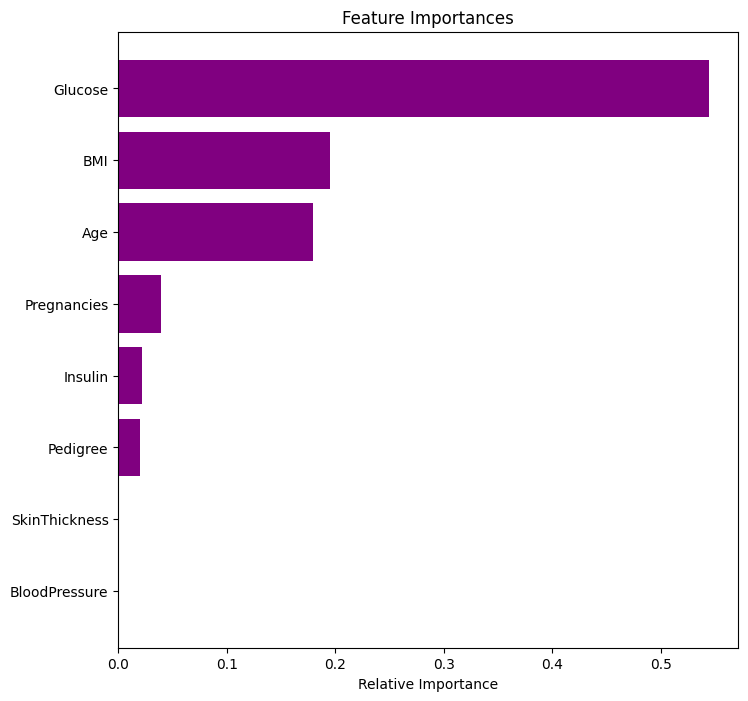

In [51]:
feature_names = X_train.columns
importances = dtree_estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,8))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

* We can see that Glucose concentration is the most important feature followed by Age and BMI.
* The tuned decision tree is using only three variables to separate the two classes. 